# Morphology prediction using GO-based gene embedding

We use gene embedding features based on the GO-based strategy in the GEARS paper

In [1]:
import pandas as pd

gene_labels = pd.read_csv('../data/cpg0016/version_2023-06-14/gene_labels.csv')

In [2]:
gene_labels

,Metadata_Symbol,Metadata_NCBI_Gene_ID,Indeterminate,Negative,Positive,gene_label
0,A2M,2,1,1,3,Positive
1,A3GALT2,127550,1,0,4,Positive
2,A4GALT,53947,0,0,5,Positive
3,A4GNT,51146,3,0,3,Indeterminate
4,AACS,65985,1,0,4,Positive
...,...,...,...,...,...,...
7970,ZSCAN32,54925,4,0,1,Indeterminate
7971,ZSCAN4,201516,0,0,3,Positive
7972,ZSCAN5A,79149,0,0,5,Positive
7973,ZSCAN9,7746,0,0,5,Positive


In [10]:
gene_labels['gene_label'].value_counts()

gene_label
Positive         6649
Indeterminate     979
Negative          347
Name: count, dtype: int64

In [3]:
import torch

gene_embeddings = torch.load('../../../data/GEARS/gene-go-embedding_2024-03-19.pt', map_location='cpu')

In [8]:
# Check overlap between computed embeddings and knockout genes
gene_labels['Metadata_Symbol'].isin(gene_embeddings['names']).value_counts()

Metadata_Symbol
True     4691
False    3284
Name: count, dtype: int64

In [9]:
# How's the label distribution on those?
limited_labels = gene_labels[gene_labels['Metadata_Symbol'].isin(gene_embeddings['names'])]
limited_labels['gene_label'].value_counts()

gene_label
Positive         4010
Indeterminate     508
Negative          173
Name: count, dtype: int64

The +/- proportion seems to be somewhat preserved in this subset. We can try predicting with this limited set.

Get definitively labeled subset of morphology data

In [15]:
definite_gene_labels = limited_labels[limited_labels.gene_label.isin(['Positive', 'Negative'])]
definite_gene_labels

,Metadata_Symbol,Metadata_NCBI_Gene_ID,Indeterminate,Negative,Positive,gene_label
4,AACS,65985,1,0,4,Positive
7,AAK1,22848,0,0,5,Positive
9,AARS,16,0,0,5,Positive
10,AARSD1,80755,1,1,5,Positive
11,AASDH,132949,0,0,5,Positive
...,...,...,...,...,...,...
7967,ZSCAN25,221785,0,0,5,Positive
7968,ZSCAN26,7741,1,0,4,Positive
7969,ZSCAN31,64288,0,0,5,Positive
7972,ZSCAN5A,79149,0,0,5,Positive


Put embedding features into a dataframe

In [14]:
embedding_df = pd.DataFrame(gene_embeddings['embedding_state_dict']['weight'], index=gene_embeddings['names'])
embedding_df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
A1BG,-1.335297e-41,-7.720314e-41,3.225789e-42,-5.856026e-42,9.363476e-42,3.730537e-41,-2.829222e-42,-1.252901e-41,-2.806801e-42,7.750582e-42,...,-1.139116e-41,3.929241e-42,-2.626314e-41,7.827653e-42,5.156778e-43,1.643303e-41,1.929728e-41,-2.282435e-41,-5.225022e-41,-1.786375e-41
AAAS,-6.373105e-42,2.312563e-41,1.946123e-41,2.621689e-41,3.100093e-41,-2.531586e-41,-4.265553e-42,-3.706715e-41,1.481873e-41,-2.912599e-41,...,-3.636930e-41,7.368027e-42,-2.719360e-41,2.069017e-41,-1.739011e-41,-2.150433e-41,2.612160e-41,-2.781157e-41,2.188688e-41,-1.584588e-41
AACS,-2.338487e-41,-1.750222e-41,1.299844e-41,6.566625e-41,7.188801e-41,1.162657e-41,-9.401311e-42,-1.578843e-41,-1.447822e-41,-1.649048e-41,...,-4.574959e-41,1.762273e-41,3.021620e-41,-1.403821e-41,-5.428770e-41,4.500971e-42,-2.891720e-41,-7.552158e-41,-6.129420e-41,3.185432e-41
AAGAB,7.505732e-04,1.183172e-03,-3.058969e-03,5.919748e-04,-6.708818e-04,-6.742178e-04,-1.167114e-03,-1.187897e-04,9.456808e-04,1.491989e-03,...,-3.959730e-04,-1.366350e-04,-2.177711e-04,7.873137e-04,8.740340e-04,7.376803e-05,-4.376333e-04,2.355867e-04,1.146066e-03,2.126177e-03
AAK1,7.581025e-43,-2.257632e-41,-4.405963e-41,3.168756e-41,-6.195701e-41,-1.944862e-41,-4.464537e-42,3.645478e-41,4.276343e-41,-1.154950e-41,...,-2.181682e-41,-6.014373e-42,1.871014e-41,2.864674e-41,-2.048838e-41,1.509339e-41,-2.900267e-41,3.738664e-42,-4.263310e-41,5.905072e-42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,-1.576040e-41,-5.078866e-41,1.406343e-41,-5.699081e-42,-3.862819e-41,6.298837e-42,4.055358e-42,7.697473e-41,2.372118e-41,-2.826279e-41,...,1.169804e-41,-1.920900e-41,-1.906467e-41,-1.249538e-41,-7.555801e-42,-1.499950e-41,-3.333689e-42,6.242785e-42,1.101421e-42,1.115434e-42
ZYG11A,-3.751556e-41,1.050694e-41,5.408452e-41,1.055738e-41,-3.034232e-41,-1.637978e-41,-1.195728e-41,-7.984178e-41,2.307518e-41,-2.880789e-41,...,-5.470669e-42,6.290849e-41,-3.002142e-41,-1.820707e-41,1.528817e-42,-3.335090e-42,3.351766e-41,-4.845130e-41,-6.896771e-41,1.550957e-41
ZYG11B,2.673958e-41,-1.490982e-41,-1.265513e-41,5.443764e-41,3.594331e-42,-1.976812e-41,2.675639e-41,-1.373833e-41,5.075503e-41,-4.362242e-42,...,-2.134458e-41,7.296561e-42,1.049713e-41,-1.623124e-41,-8.019631e-42,3.241484e-41,1.692769e-42,-1.599162e-41,8.420402e-42,-1.300405e-41
ZYX,-3.859596e-41,-1.975130e-41,-3.062818e-41,-3.520342e-41,1.751903e-41,1.513542e-41,-7.275822e-41,3.282261e-41,-6.193739e-43,-1.536804e-41,...,1.197830e-41,-1.534982e-41,-9.446153e-42,4.556322e-41,-5.344552e-42,1.416432e-41,1.774745e-41,-1.246175e-41,3.673224e-41,4.565430e-42


For subsequent analysis, we'll use genes that are both labeled and have abundance data.

In [16]:
labeled_df = (
    definite_gene_labels[['Metadata_Symbol', 'gene_label']]
    .merge(
        embedding_df,
        how='inner',
        left_on='Metadata_Symbol',
        right_index=True
    )
)
labeled_df

,Metadata_Symbol,gene_label,0,1,2,3,4,5,6,7,...,54,55,56,57,58,59,60,61,62,63
4,AACS,Positive,-2.338487e-41,-1.750222e-41,1.299844e-41,6.566625e-41,7.188801e-41,1.162657e-41,-9.401311e-42,-1.578843e-41,...,-4.574959e-41,1.762273e-41,3.021620e-41,-1.403821e-41,-5.428770e-41,4.500971e-42,-2.891720e-41,-7.552158e-41,-6.129420e-41,3.185432e-41
7,AAK1,Positive,7.581025e-43,-2.257632e-41,-4.405963e-41,3.168756e-41,-6.195701e-41,-1.944862e-41,-4.464537e-42,3.645478e-41,...,-2.181682e-41,-6.014373e-42,1.871014e-41,2.864674e-41,-2.048838e-41,1.509339e-41,-2.900267e-41,3.738664e-42,-4.263310e-41,5.905072e-42
9,AARS,Positive,2.453674e-41,-1.909409e-41,1.182556e-41,2.294626e-41,-2.889898e-41,1.937435e-41,2.373239e-41,-7.729562e-42,...,-3.803124e-42,-5.409012e-42,4.386064e-42,-3.912145e-41,-2.365392e-41,2.250065e-41,-2.071119e-41,2.262256e-41,-1.649188e-41,2.252027e-41
10,AARSD1,Positive,-2.087514e-41,7.062544e-43,-1.114313e-41,2.835247e-41,-1.119217e-41,-2.923669e-41,2.375341e-41,-6.209153e-42,...,-1.766337e-41,2.911898e-41,-1.535543e-41,8.009822e-42,1.964480e-41,5.109134e-42,-7.758990e-42,3.485029e-42,-9.262583e-43,2.134178e-41
11,AASDH,Positive,5.196855e-41,-1.407184e-41,-3.095328e-41,2.055425e-41,4.924163e-42,-8.081288e-42,1.971347e-41,1.255563e-42,...,1.481873e-41,1.329132e-41,5.397381e-41,1.543951e-41,1.888810e-41,-1.336839e-42,2.108814e-41,1.555441e-41,3.621095e-41,-1.495606e-41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7967,ZSCAN25,Positive,1.285551e-41,-1.244493e-41,2.848700e-41,-4.410867e-41,-4.702758e-42,2.436298e-41,-1.571836e-41,-1.433949e-41,...,1.203996e-41,1.081802e-42,1.862746e-41,1.776846e-42,1.489020e-41,1.095115e-41,1.212544e-41,-3.965815e-41,-4.366446e-42,1.631111e-41
7968,ZSCAN26,Positive,-9.801692e-04,-8.823524e-04,5.643500e-03,-1.503309e-03,1.211834e-03,8.983174e-04,2.670672e-04,-1.111262e-03,...,1.405683e-03,-2.890921e-04,8.607776e-04,-1.278333e-03,6.864676e-04,-7.436806e-04,-1.183144e-03,-1.317575e-03,1.053109e-02,-9.027438e-04
7969,ZSCAN31,Positive,-2.201300e-41,-1.090631e-41,-1.462675e-41,1.873536e-41,4.550437e-41,-1.843268e-41,1.269997e-41,-3.627541e-41,...,5.397802e-42,-1.936735e-41,-8.072740e-41,1.605187e-41,-4.092352e-41,3.650382e-42,7.998612e-42,-3.191037e-41,2.058367e-41,-3.195941e-41
7972,ZSCAN5A,Positive,2.076444e-41,-1.920480e-41,-1.077599e-41,-1.299704e-41,1.592856e-41,1.171626e-41,1.609812e-41,-2.551064e-41,...,-3.009989e-42,1.836262e-41,5.045936e-41,2.306117e-41,-2.248944e-41,-3.279599e-41,6.618333e-42,-1.660399e-41,-3.388900e-41,3.256618e-42


Construct vectors for ML

In [17]:
all_columns = labeled_df.columns
x_columns = all_columns.drop(['Metadata_Symbol', 'gene_label'])
x = labeled_df[x_columns]
y = labeled_df['gene_label'].map({'Positive': 1, 'Negative': 0})

In [18]:
x

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
4,-2.338487e-41,-1.750222e-41,1.299844e-41,6.566625e-41,7.188801e-41,1.162657e-41,-9.401311e-42,-1.578843e-41,-1.447822e-41,-1.649048e-41,...,-4.574959e-41,1.762273e-41,3.021620e-41,-1.403821e-41,-5.428770e-41,4.500971e-42,-2.891720e-41,-7.552158e-41,-6.129420e-41,3.185432e-41
7,7.581025e-43,-2.257632e-41,-4.405963e-41,3.168756e-41,-6.195701e-41,-1.944862e-41,-4.464537e-42,3.645478e-41,4.276343e-41,-1.154950e-41,...,-2.181682e-41,-6.014373e-42,1.871014e-41,2.864674e-41,-2.048838e-41,1.509339e-41,-2.900267e-41,3.738664e-42,-4.263310e-41,5.905072e-42
9,2.453674e-41,-1.909409e-41,1.182556e-41,2.294626e-41,-2.889898e-41,1.937435e-41,2.373239e-41,-7.729562e-42,-1.572257e-41,-3.446634e-41,...,-3.803124e-42,-5.409012e-42,4.386064e-42,-3.912145e-41,-2.365392e-41,2.250065e-41,-2.071119e-41,2.262256e-41,-1.649188e-41,2.252027e-41
10,-2.087514e-41,7.062544e-43,-1.114313e-41,2.835247e-41,-1.119217e-41,-2.923669e-41,2.375341e-41,-6.209153e-42,2.009042e-41,1.583607e-41,...,-1.766337e-41,2.911898e-41,-1.535543e-41,8.009822e-42,1.964480e-41,5.109134e-42,-7.758990e-42,3.485029e-42,-9.262583e-43,2.134178e-41
11,5.196855e-41,-1.407184e-41,-3.095328e-41,2.055425e-41,4.924163e-42,-8.081288e-42,1.971347e-41,1.255563e-42,-1.773343e-41,2.617345e-41,...,1.481873e-41,1.329132e-41,5.397381e-41,1.543951e-41,1.888810e-41,-1.336839e-42,2.108814e-41,1.555441e-41,3.621095e-41,-1.495606e-41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7967,1.285551e-41,-1.244493e-41,2.848700e-41,-4.410867e-41,-4.702758e-42,2.436298e-41,-1.571836e-41,-1.433949e-41,-1.160976e-41,2.432934e-41,...,1.203996e-41,1.081802e-42,1.862746e-41,1.776846e-42,1.489020e-41,1.095115e-41,1.212544e-41,-3.965815e-41,-4.366446e-42,1.631111e-41
7968,-9.801692e-04,-8.823524e-04,5.643500e-03,-1.503309e-03,1.211834e-03,8.983174e-04,2.670672e-04,-1.111262e-03,-9.663744e-04,-1.306751e-03,...,1.405683e-03,-2.890921e-04,8.607776e-04,-1.278333e-03,6.864676e-04,-7.436806e-04,-1.183144e-03,-1.317575e-03,1.053109e-02,-9.027438e-04
7969,-2.201300e-41,-1.090631e-41,-1.462675e-41,1.873536e-41,4.550437e-41,-1.843268e-41,1.269997e-41,-3.627541e-41,-2.915261e-41,-1.012859e-41,...,5.397802e-42,-1.936735e-41,-8.072740e-41,1.605187e-41,-4.092352e-41,3.650382e-42,7.998612e-42,-3.191037e-41,2.058367e-41,-3.195941e-41
7972,2.076444e-41,-1.920480e-41,-1.077599e-41,-1.299704e-41,1.592856e-41,1.171626e-41,1.609812e-41,-2.551064e-41,1.850274e-41,1.747699e-41,...,-3.009989e-42,1.836262e-41,5.045936e-41,2.306117e-41,-2.248944e-41,-3.279599e-41,6.618333e-42,-1.660399e-41,-3.388900e-41,3.256618e-42


ML Run

/ua/yuriy/mambaforge/envs/pyg-gears/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/ua/yuriy/mambaforge/envs/pyg-gears/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/lin

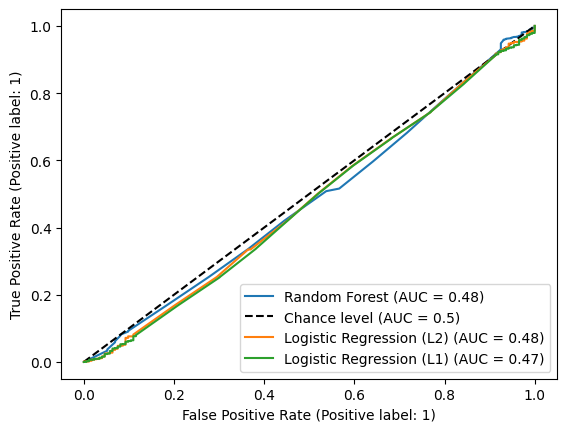

In [19]:
# Defining inputs for machine learning models
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.metrics import roc_curve, auc, accuracy_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize, LabelEncoder
from matplotlib.pyplot import subplots

models = {
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression (L2)':
        Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(penalty='l2'))
        ]),
    'Logistic Regression (L1)':
        Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(penalty='l1', solver='liblinear'))
        ])
}

cv = StratifiedKFold(n_splits=10, random_state=20240131, shuffle=True)

ax = None

for name, model in models.items():
    probs = cross_val_predict(model, x, y, cv=cv, method='predict_proba')[:, 1]
    fig = RocCurveDisplay.from_predictions(y, probs, name=name, plot_chance_level=(ax is None), ax=ax)
    ax = fig.ax_

/ua/yuriy/mambaforge/envs/pyg-gears/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/ua/yuriy/mambaforge/envs/pyg-gears/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/lin

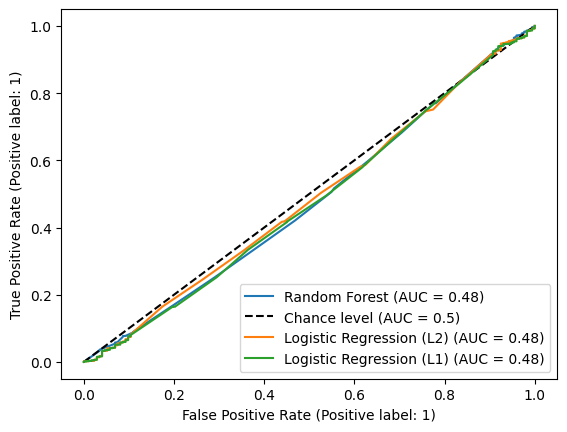

In [20]:
models = {
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression (L2)':
        Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(penalty='l2', class_weight='balanced'))
        ]),
    'Logistic Regression (L1)':
        Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
        ])
}

ax = None

for name, model in models.items():
    probs = cross_val_predict(model, x, y, cv=cv, method='predict_proba')[:, 1]
    fig = RocCurveDisplay.from_predictions(y, probs, name=name, plot_chance_level=(ax is None), ax=ax)
    ax = fig.ax_